In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the Product Monthly Panel dataset
file_path = 'product_monthly_panel.csv'
product_df = pd.read_csv(file_path)

# Display the first few rows
print("First five rows of the dataset:")
print(product_df.head())

# Selecting numerical features for clustering
numerical_cols = ['rating', 'helpfulness', 'total_feedback_count',
                  'total_neg_feedback_count', 'total_pos_feedback_count', 'price_usd']
product_numeric = product_df[numerical_cols].dropna()


First five rows of the dataset:
  product_id submission_time  rating  is_recommended  helpfulness  \
0    P107306      2008-09-30     4.0             NaN     0.883333   
1    P107306      2008-10-31     4.5             NaN     0.833333   
2    P107306      2008-11-30     1.0             NaN     0.833333   
3    P107306      2008-12-31     4.5             NaN     0.750000   
4    P107306      2009-01-31     5.0             NaN     0.833333   

   total_feedback_count  total_neg_feedback_count  total_pos_feedback_count  \
0                    15                         2                        13   
1                     6                         1                         5   
2                     6                         1                         5   
3                     6                         1                         5   
4                     8                         2                         6   

   price_usd brand_name  skin_tone eye_color    skin_type hair_color  
0      

In [2]:
# Standardizing the features
scaler = StandardScaler()
product_scaled = scaler.fit_transform(product_numeric)

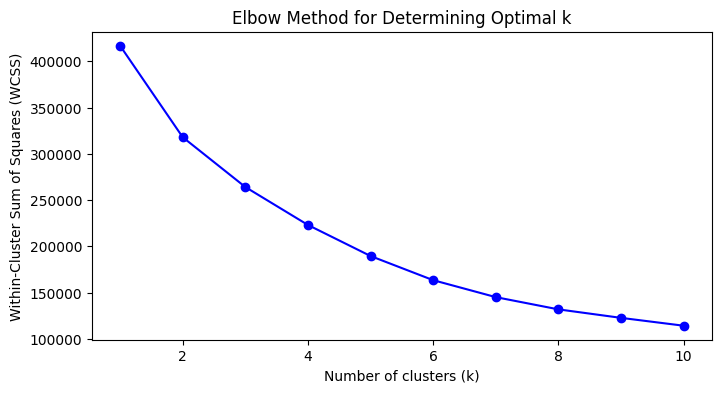

In [3]:
# Determine the optimal number of clusters using the Elbow Method
wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(product_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(8, 4))
plt.plot(K_range, wcss, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Determining Optimal k')
plt.show()

In [5]:
# Choosing the optimal k based on the elbow method
optimal_k = 3  # Adjust based on the elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Ensure clustering is applied only to the cleaned subset
product_numeric['Cluster'] = kmeans.fit_predict(product_scaled)

In [7]:
from sklearn.utils import resample  # Import for sampling

# Compute silhouette score on a subset of the data to speed up processing
sample_size = min(5000, len(product_scaled))  # Limit to 5000 samples or the dataset size
sampled_data, sampled_labels = resample(product_scaled, product_numeric['Cluster'], n_samples=sample_size, random_state=42)

silhouette_avg = silhouette_score(sampled_data, sampled_labels)
print(f"Silhouette Score for k={optimal_k}: {silhouette_avg:.2f}")


Silhouette Score for k=3: 0.34


In [8]:
# Reduce dimensions using PCA for visualization
pca = PCA(n_components=2)
product_pca = pca.fit_transform(product_scaled)
product_numeric['PCA1'] = product_pca[:, 0]
product_numeric['PCA2'] = product_pca[:, 1]

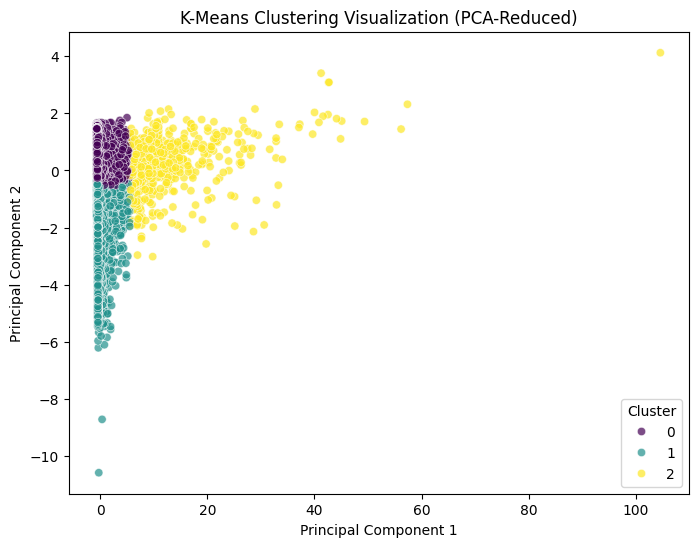

In [9]:
# Merge clustering results back into the original DataFrame
product_df = product_df.loc[product_numeric.index].copy()
product_df['Cluster'] = product_numeric['Cluster']
product_df['PCA1'] = product_numeric['PCA1']
product_df['PCA2'] = product_numeric['PCA2']

# Visualizing Clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=product_df, palette='viridis', alpha=0.7)
plt.title('K-Means Clustering Visualization (PCA-Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [10]:
# Display cluster counts
print("\nCluster Counts:")
print(product_df['Cluster'].value_counts())


Cluster Counts:
Cluster
0    49376
1    19315
2      780
Name: count, dtype: int64
